---
# This script will create global-mean T (anomaly) profiles for Fig. 3. I'm preparing the data/global means to implement the density-weighted region-stratified bootstrapped CI's
#### 6/22/26
---

In [1]:
# kernel: pangeo23

In [2]:
# imports
import os
import xarray as xr
import numpy as np
import netCDF4 
import glob
import pandas as pd
import geopandas as gpd
from datetime import datetime
from scipy import stats
from scipy.spatial import cKDTree

from coastal_analysis_fns import *

import warnings
warnings.filterwarnings('ignore')

In [3]:
# interactive plotting stuff 
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import colors
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
from matplotlib import rcParams
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.lines import Line2D 

#import matplotlib.dates as mdates
%matplotlib inline
plt.rcParams['figure.figsize'] = 12, 6
#%config InlineBackend.figure_format = 'retina'

import cartopy
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point

In [4]:
def bin_lat_scatters_densitywtd_bootCI_forTProfiles(latbins, lats, lons, dat, nboot, radius_deg):
    '''
    Like "bin_lat_scatters_densitywtd_bootCI()" but this one takes in a 2-d "dat" array so that I can randomly sample T profiles (maintaining the spatial structure,
     rather than generating a bootstrapped mean level-by-level)

    6/22/26

    ### 6/23 I THINK I MESSED UP! THAT MIGHT BE WHY I'M HAVING ISSUES WITH THE Tprofiles... ### am I only doing 1 run-thru aka only 1 lat bin?
        # I was only running thru 1 lat-bin... I had the function returning values at the end of the first forloop!!! now it's fixed.
    '''

#    print('called bin_lat_scatters_densitywtd_bootCI_forTProfiles()')
    
    # random seed
    rng = np.random.default_rng(27)
    
    # empty arrays to hold output
    binned_boots = np.zeros(shape=(len(latbins)-1, nboot, 12)) * np.nan # dims = [lat_bin, bootstrap_mean_draw, level]
    bin_midpoints = np.zeros(len(latbins)-1)
    bin_n_obs = np.zeros(len(latbins)-1)
    
    i = 0
    
    # for each lat bin
    while i < len(latbins)-1:

#        print(i)
        
        # sel lat bin bounds, generate bin mask
        bot_bin = latbins[i]
        top_bin = latbins[i+1]
        binmask = (lats >= bot_bin) * (lats < top_bin)
    
    #        print(i, bot_bin, top_bin)
    
        # skip bin if there are no obs in that bin
        if np.sum(binmask) == 0:
    #            print('skip this bin.')
            bin_midpoints[i] = ((bot_bin+top_bin)/2)
            bin_n_obs[i] = 0
            i += 1
            continue
    
        # set vals to send to bootstrap
        dat_bin = dat[binmask] # this still makes 2-d, nice
        lats_bin = lats[binmask]
        lons_bin = lons[binmask]
        
        # distance-weights for this lat bin
        weights = compute_density_weights(lats=lats_bin, lons=lons_bin, radius_deg=radius_deg)
        
        # empty array to store bootstrap draws
        boot_stats = (np.zeros(shape=(nboot, 12)) * np.nan) # shape is now [nboot, level]
        
        # do the bootstrapped mean
        for b in range(nboot):
            idx = rng.choice(len(dat_bin), size=len(dat_bin), replace=True, p=weights)
        
            # 6/21/26 - adding another step to ignore inf when taking the mean
            ddd = dat_bin[idx]
            no_inf_mask = np.logical_not(np.isinf(ddd))
            ddd_masked = np.where(no_inf_mask, ddd, np.nan) # replace any inf's with NaN
        
            # compute the bootstrapped mean
            boot_stats[b, :] = np.nanmean(ddd_masked, axis=0) 
        
        # add the results to the output arrays
        binned_boots[i, :, :] = boot_stats
        bin_midpoints[i] = ((bot_bin+top_bin)/2)
        bin_n_obs[i] = np.sum(binmask)
    
        # update counter
        i += 1 

    ## FIXED? I THINK
    return binned_boots, bin_midpoints, bin_n_obs 

In [5]:
# script name
script = os.getcwd() + 'analyze_Tprofiles_with_bootstrap.ipynb'

In [6]:
# dataframe with the stations we are using
df = pd.read_csv('/home/nsiegert/projects/coastal_sst/data/hadisd_stations_using_Expanded.csv')
df = df.drop(['Unnamed: 0'], axis=1)

In [7]:
# lat bins
lbins = np.arange(-60, 71, 3)

--------------------------
15deg w mhw


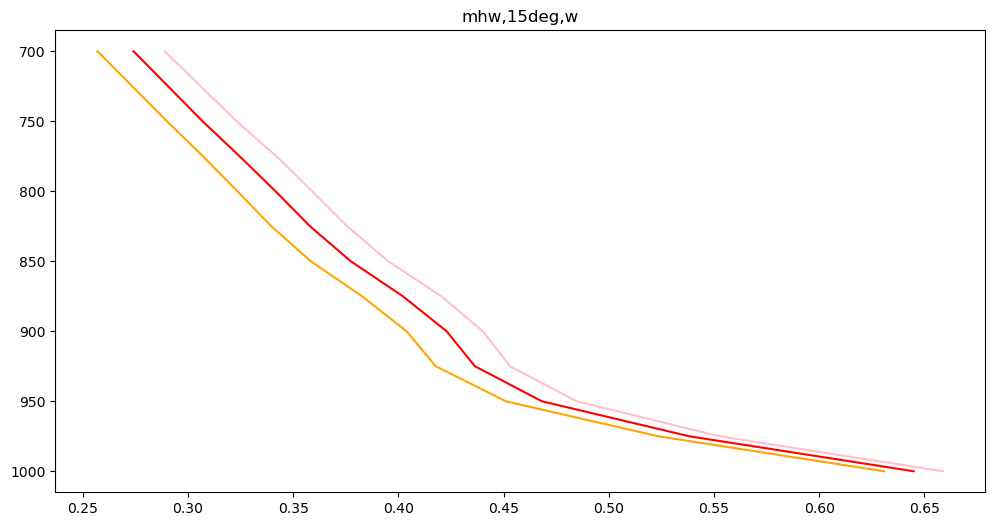

--------------------------
15deg w thw


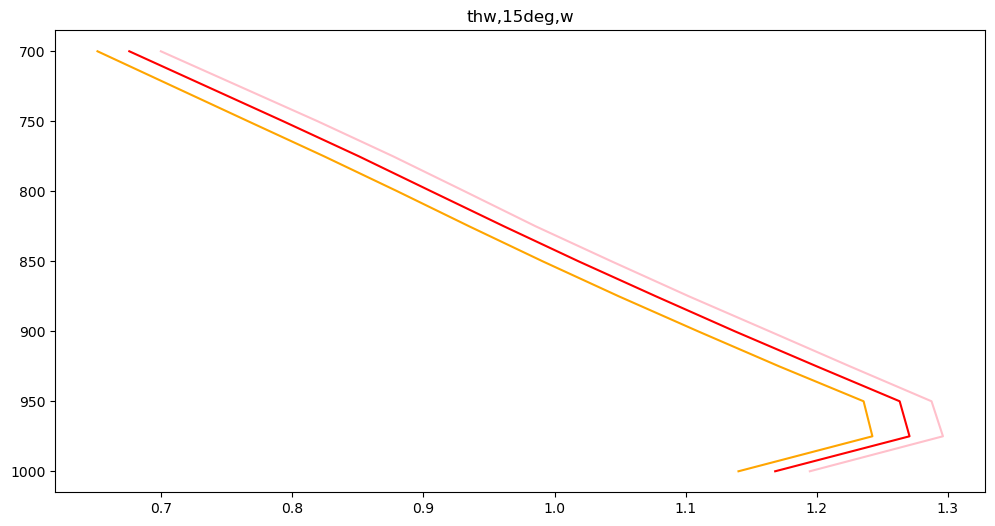

--------------------------
15deg w con


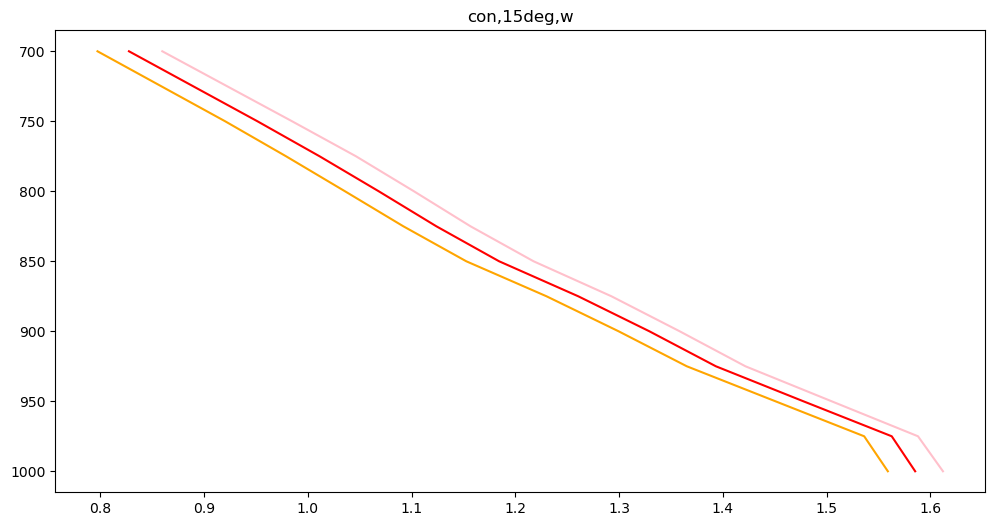

--------------------------
15deg c mhw


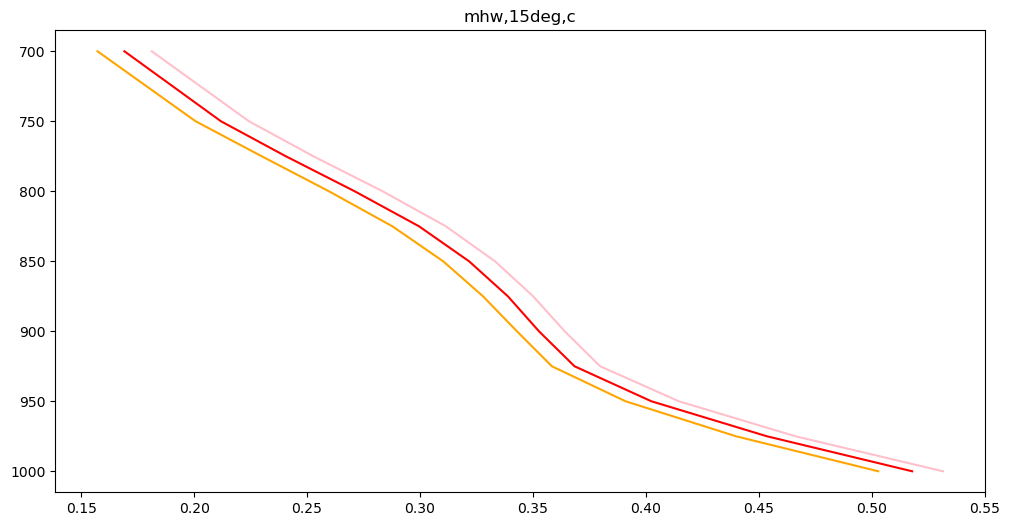

--------------------------
15deg c thw


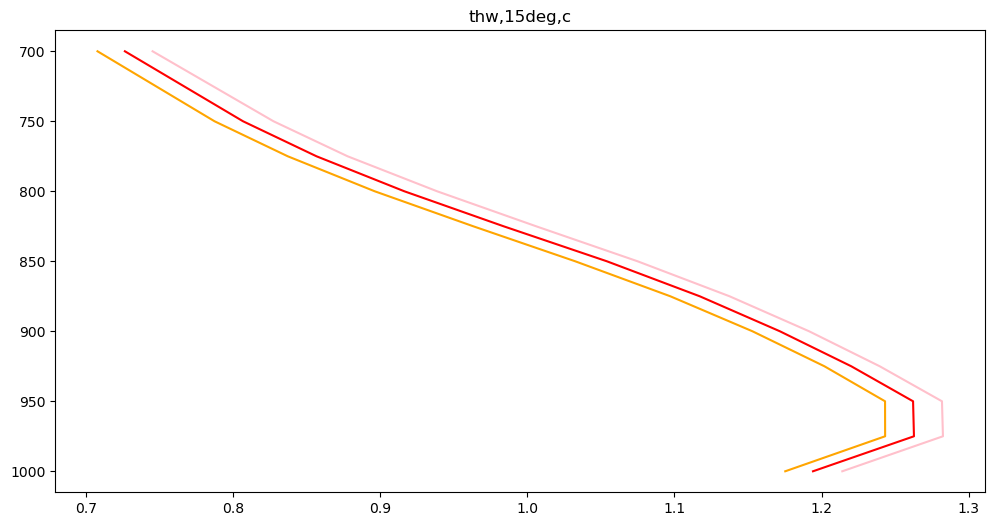

--------------------------
15deg c con


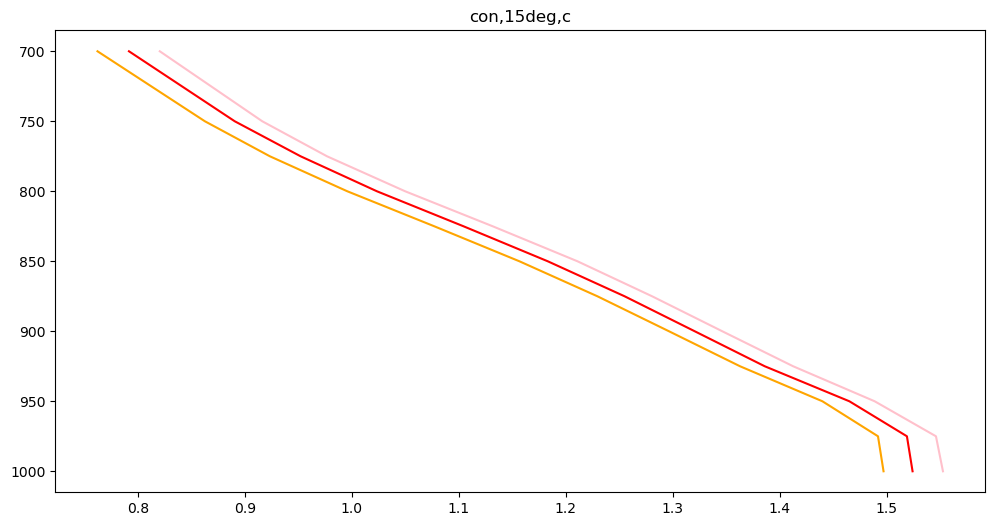

--------------------------
STA w mhw


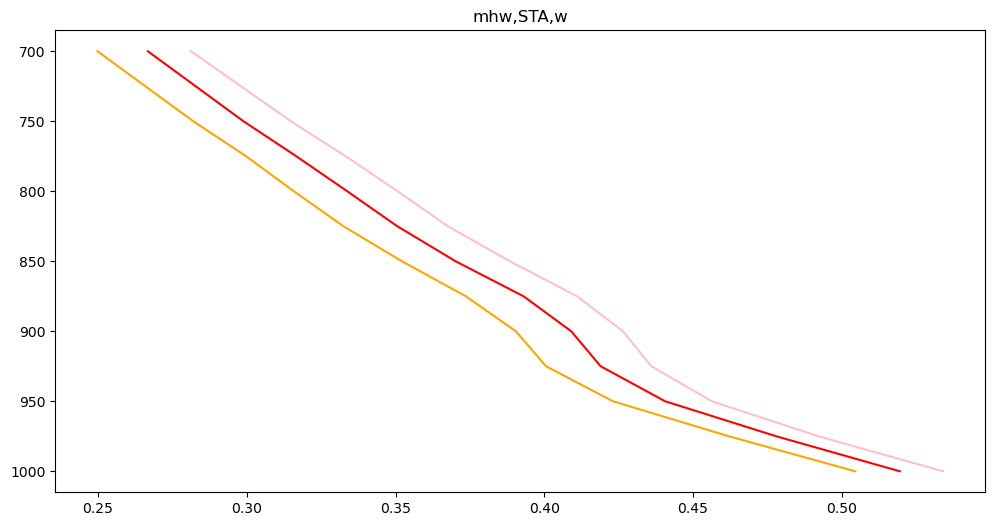

--------------------------
STA w thw


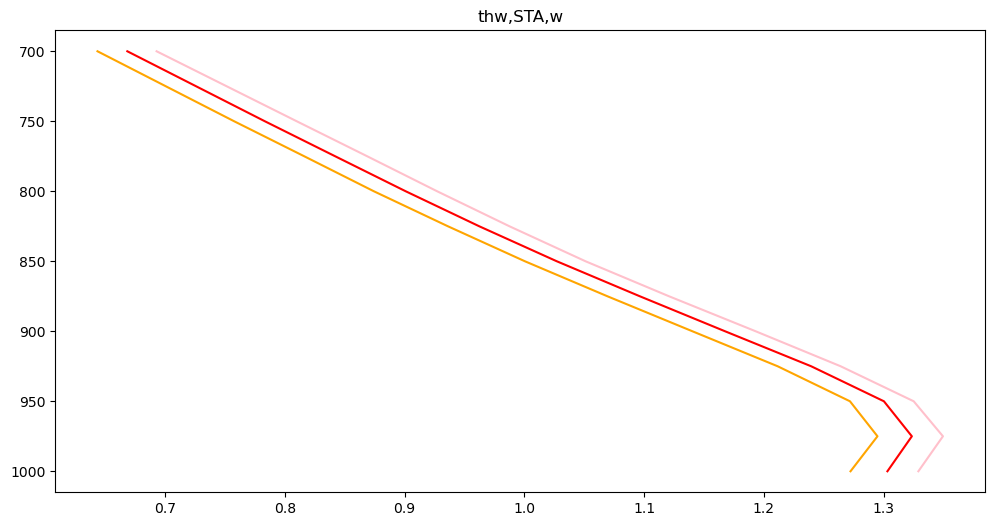

--------------------------
STA w con


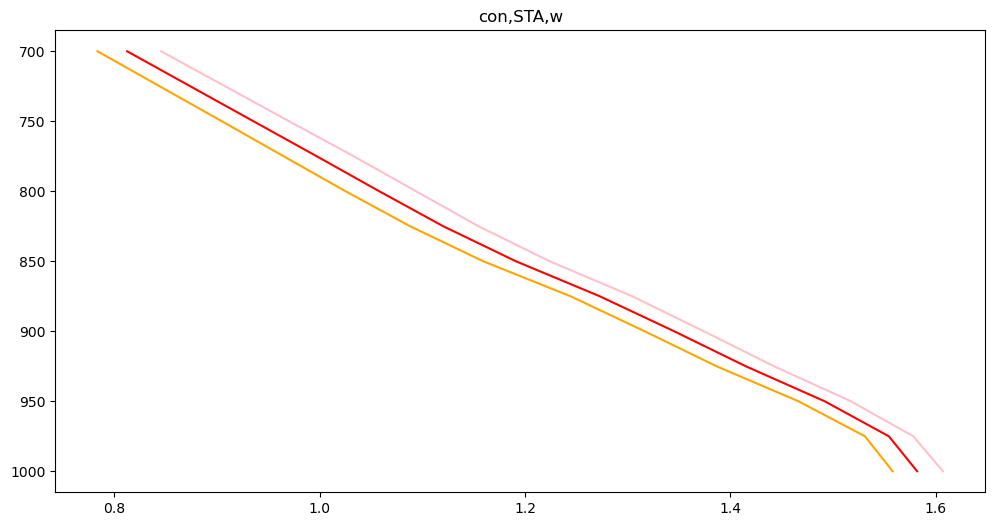

--------------------------
STA c mhw


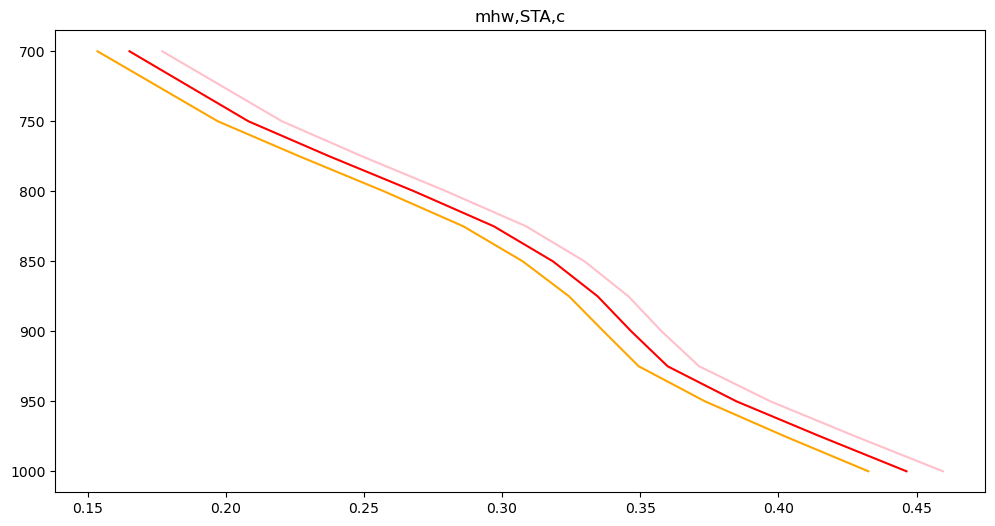

--------------------------
STA c thw


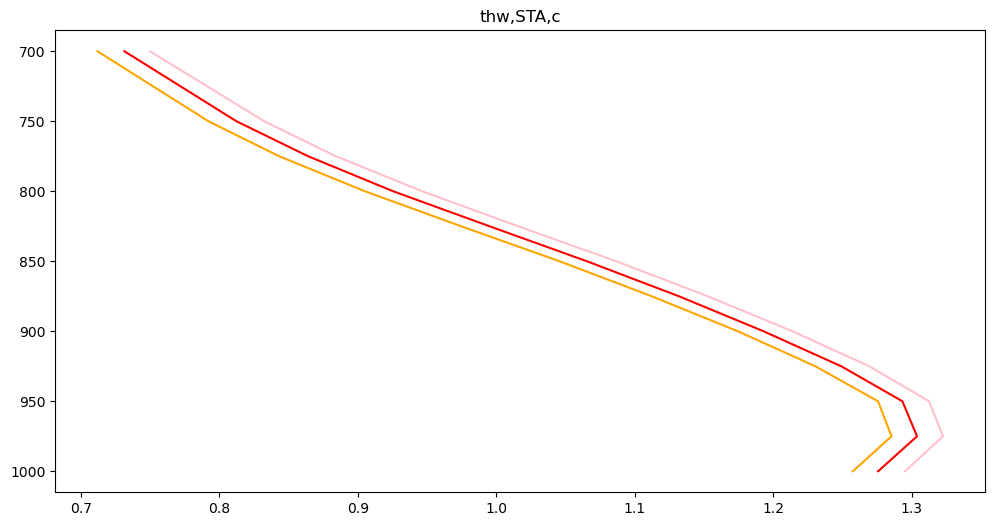

--------------------------
STA c con


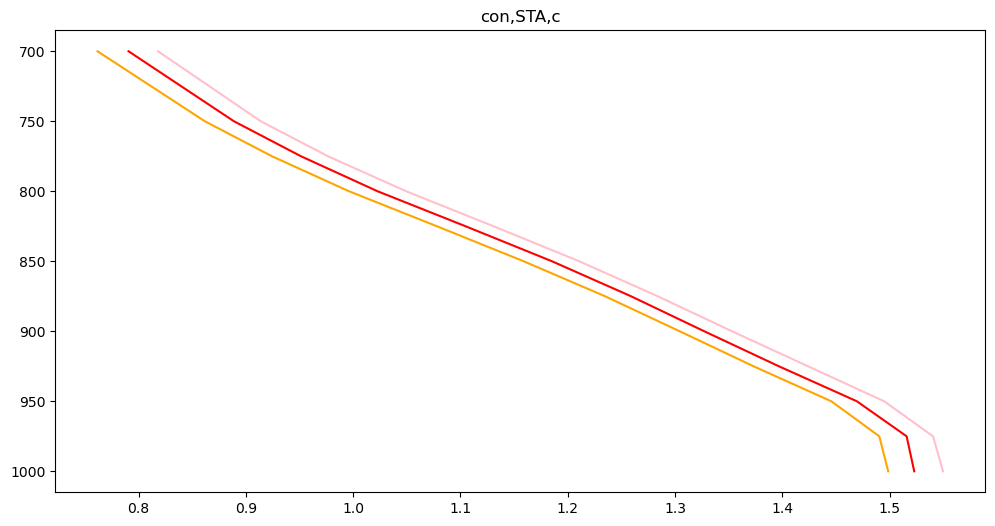

In [8]:
# load in the data in nested dicts
in_data_dict = {}

for domain in ['15deg', 'STA']:

    in_data_dict[domain] = {}
    
    for szn in ['w', 'c']:

        in_data_dict[domain][szn] = {}

        for ev_type in ['mhw', 'thw', 'con']:

            print('--------------------------')
            print(domain, szn, ev_type)
            in_data_dict[domain][szn][ev_type] = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/{}_{}_Tprofile_anom_ds_{}.nc'.format(ev_type, domain, szn)).Tx_anom

            # I guess I can compute the bootstrapped stuff here as well...
            binned_boots, bin_midpoints, bin_nobs = bin_lat_scatters_densitywtd_bootCI_forTProfiles(latbins=lbins, lats=df.LAT.values, lons=df.LON.values, 
                                                            dat=in_data_dict[domain][szn][ev_type].data, nboot=1000, radius_deg=3.0)

            # put into DataArray
            bin_boot_da = xr.DataArray(binned_boots, dims=['lat bin', 'boot', 'level'], coords={'lat bin':bin_midpoints, 'boot':np.array(range(1000)), 'level':in_data_dict[domain][szn][ev_type].level})


            # aggregate bins to global-mean scale, weighting by bin land area
            globalmean_boot_da = bin_boot_da.weighted(np.cos(np.deg2rad(bin_boot_da['lat bin']))).mean(dim='lat bin')

            # now, take bootstrapped mean and 95% CI of the global profiles
            globalmean_bootprofile_med = globalmean_boot_da.quantile(0.5, dim='boot')
            globalmean_bootprofile_hici = globalmean_boot_da.quantile(0.975, dim='boot')
            globalmean_bootprofile_loci = globalmean_boot_da.quantile(0.025, dim='boot')

            # now plot...
            levels = in_data_dict[domain][szn][ev_type].level
            fig, ax = plt.subplots()
            ax.plot(globalmean_bootprofile_med, levels, color='red')
            ax.plot(globalmean_bootprofile_hici, levels, color='pink')
            ax.plot(globalmean_bootprofile_loci, levels, color='orange')
            ax.set(title='{},{},{}'.format(ev_type, domain, szn))
            ax.invert_yaxis()
            plt.pause(0.1)

            
            # ... save so that I can analyze/plot over in the Fig. 3 script
            ds_out = bin_boot_da.to_dataset(name='Tx_anom')
            ds_out.attrs['script'] = script
            now = datetime.now()
            ds_out.attrs['timestamp'] = now.strftime("%Y-%m-%d %H:%M:%S")
            ds_out.to_netcdf('/dx02/data/nsiegert/coastal_mhw_data/{}_{}_Bootstrap_Tprofile_anom_ds_{}.nc'.format(ev_type, domain, szn))

----

### this code shows the old version before I (think) fixed it

--------------------------
15deg w mhw
called bin_lat_scatters_densitywtd_bootCI_forTProfiles()
0
1


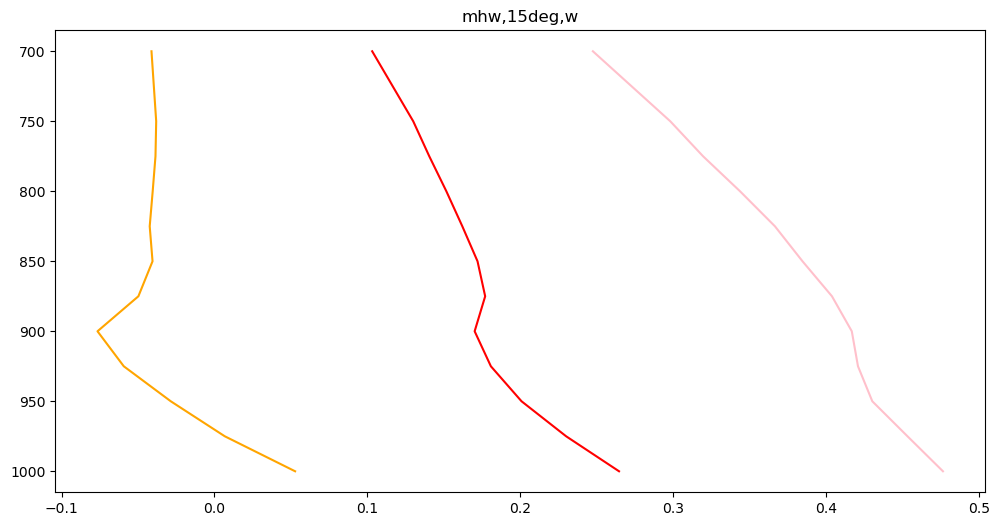

--------------------------
15deg w thw
called bin_lat_scatters_densitywtd_bootCI_forTProfiles()
0
1


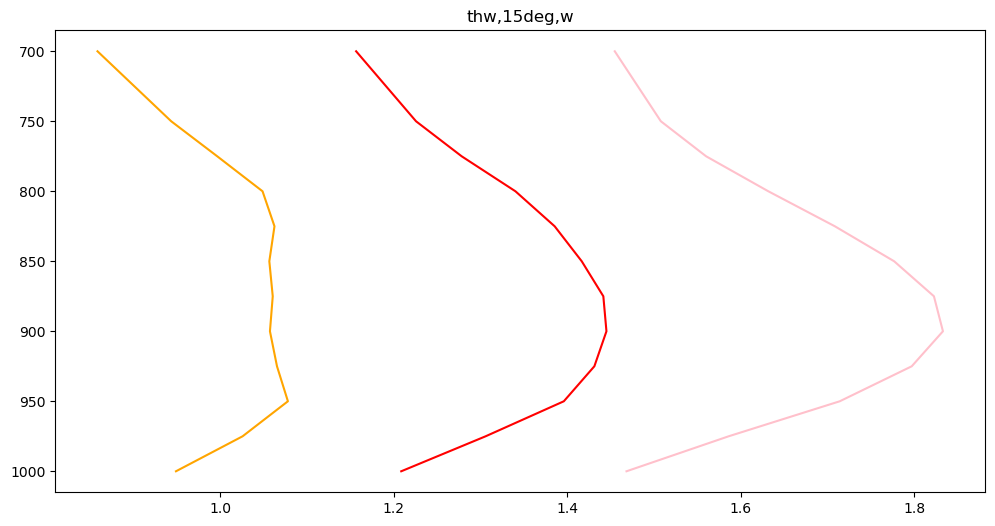

--------------------------
15deg w con
called bin_lat_scatters_densitywtd_bootCI_forTProfiles()
0
1


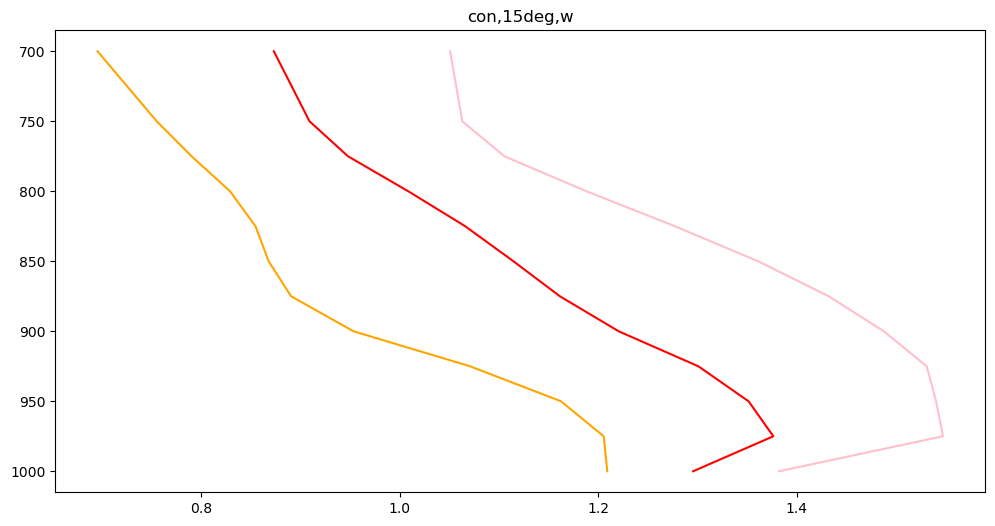

--------------------------
15deg c mhw
called bin_lat_scatters_densitywtd_bootCI_forTProfiles()
0
1


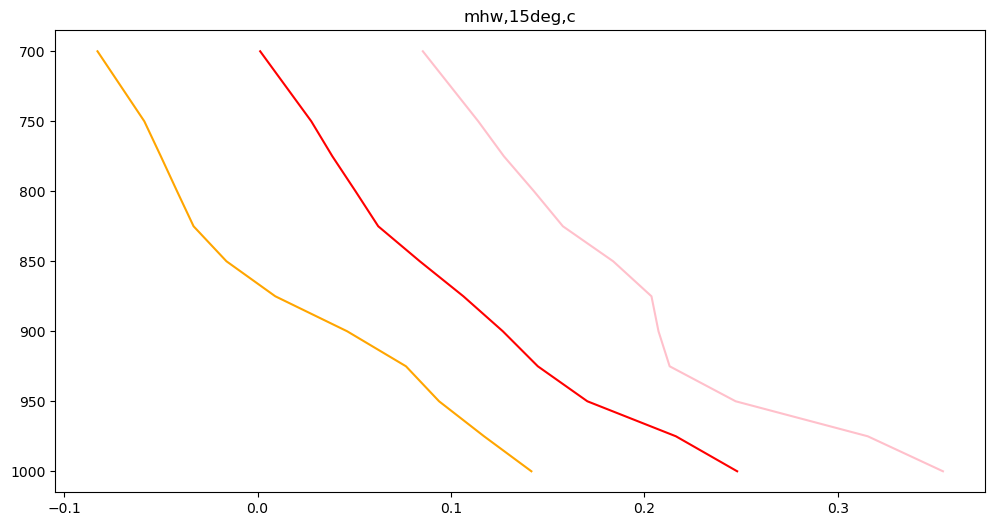

--------------------------
15deg c thw
called bin_lat_scatters_densitywtd_bootCI_forTProfiles()
0
1


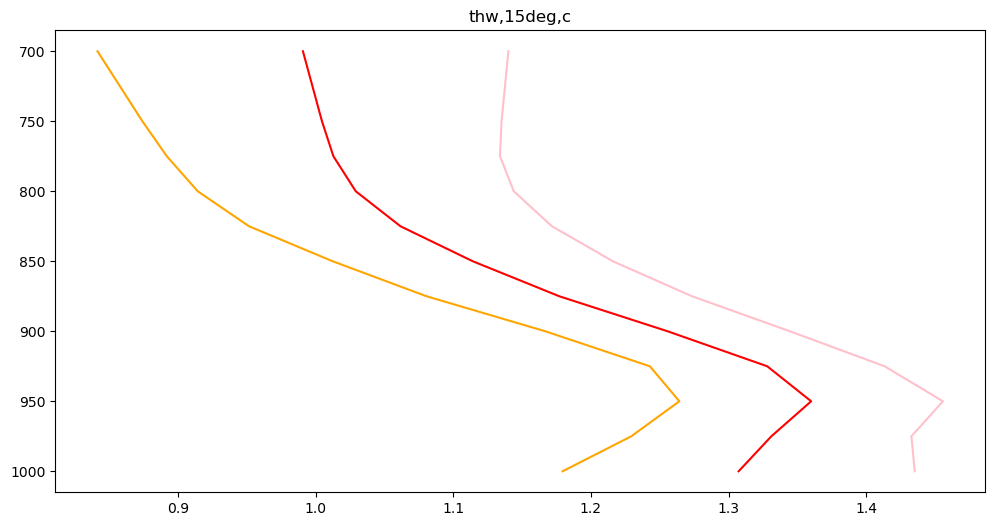

--------------------------
15deg c con
called bin_lat_scatters_densitywtd_bootCI_forTProfiles()
0
1


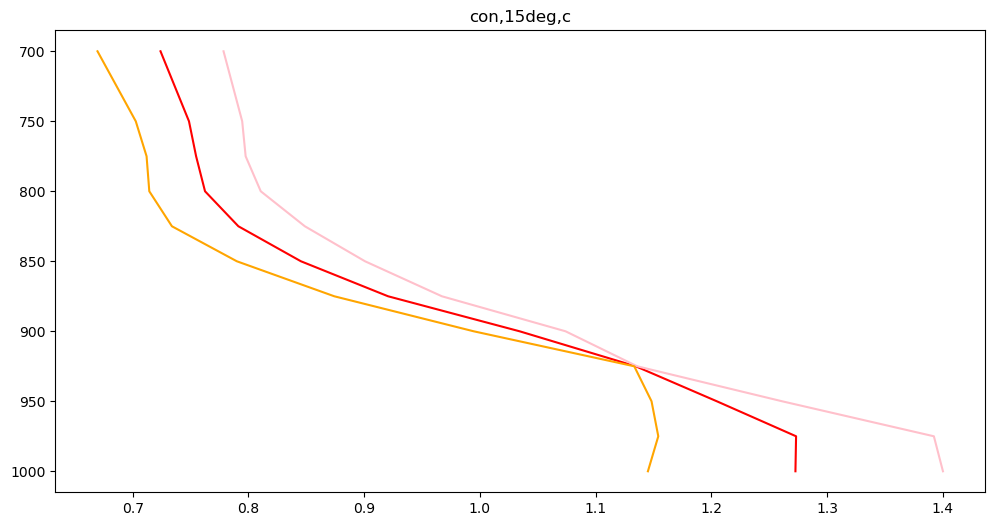

--------------------------
STA w mhw
called bin_lat_scatters_densitywtd_bootCI_forTProfiles()
0
1


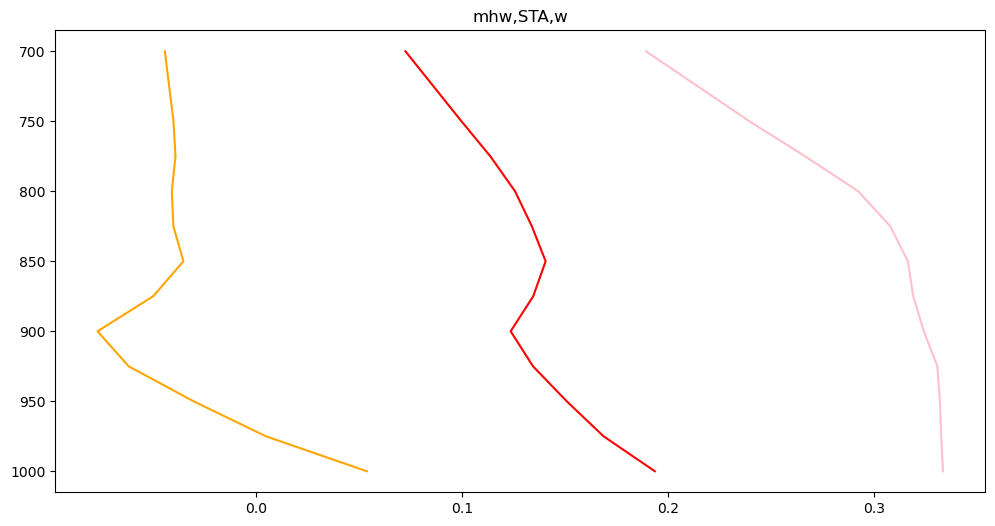

--------------------------
STA w thw
called bin_lat_scatters_densitywtd_bootCI_forTProfiles()
0
1


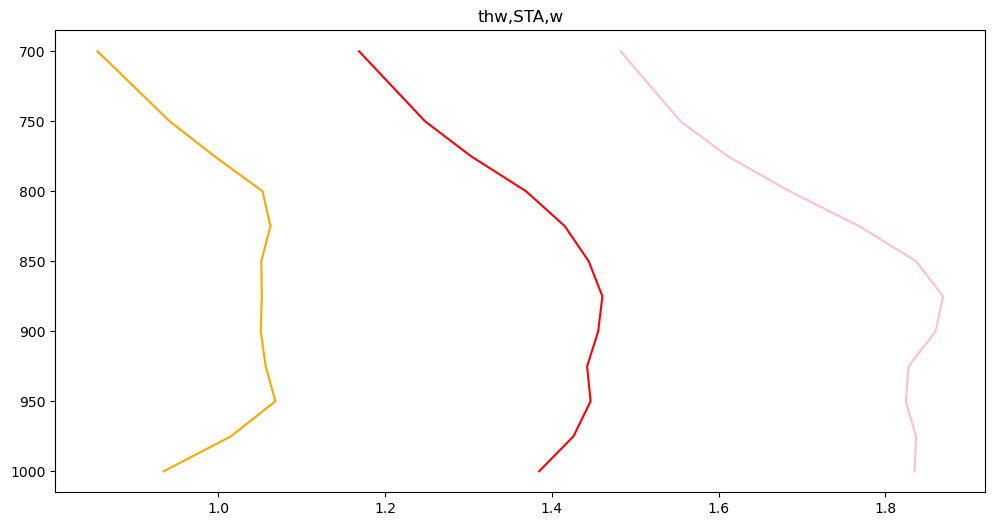

--------------------------
STA w con
called bin_lat_scatters_densitywtd_bootCI_forTProfiles()
0
1


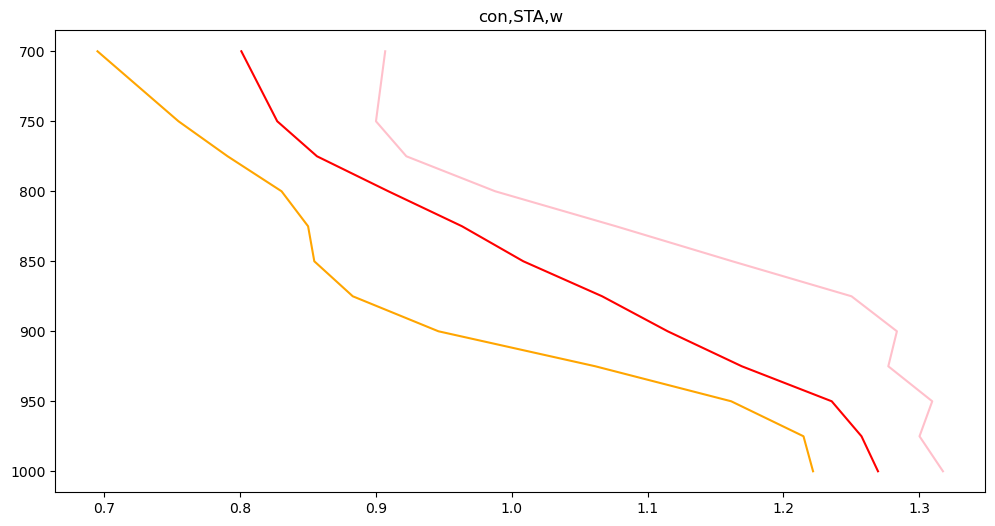

--------------------------
STA c mhw
called bin_lat_scatters_densitywtd_bootCI_forTProfiles()
0
1


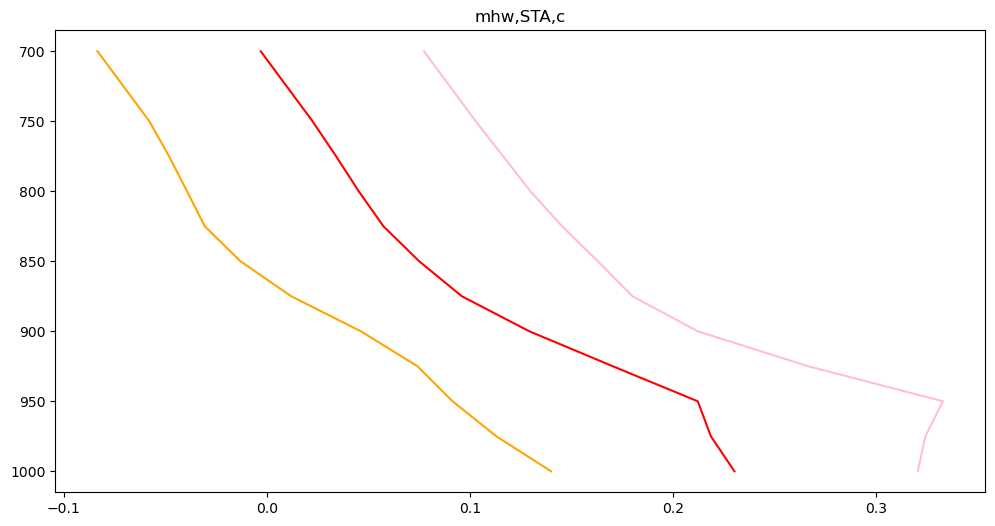

--------------------------
STA c thw
called bin_lat_scatters_densitywtd_bootCI_forTProfiles()
0
1


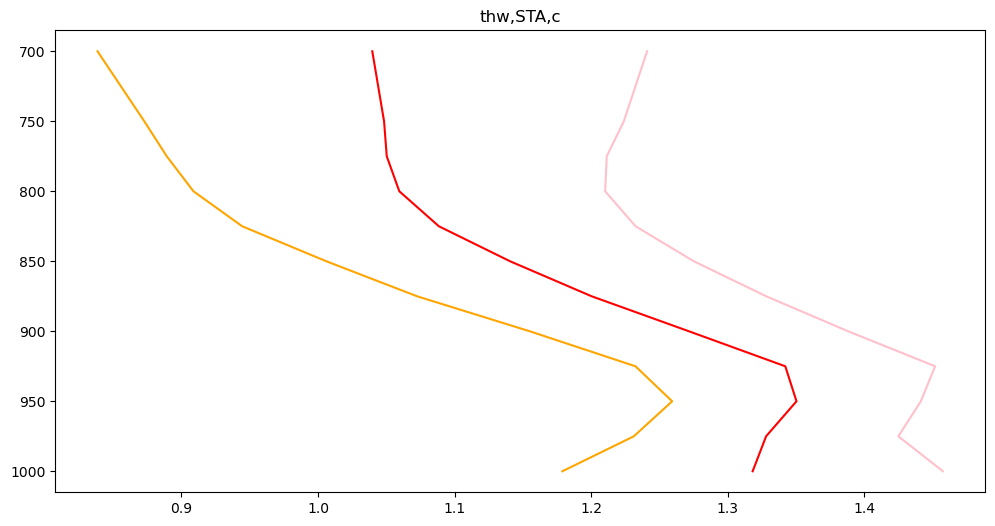

--------------------------
STA c con
called bin_lat_scatters_densitywtd_bootCI_forTProfiles()
0
1


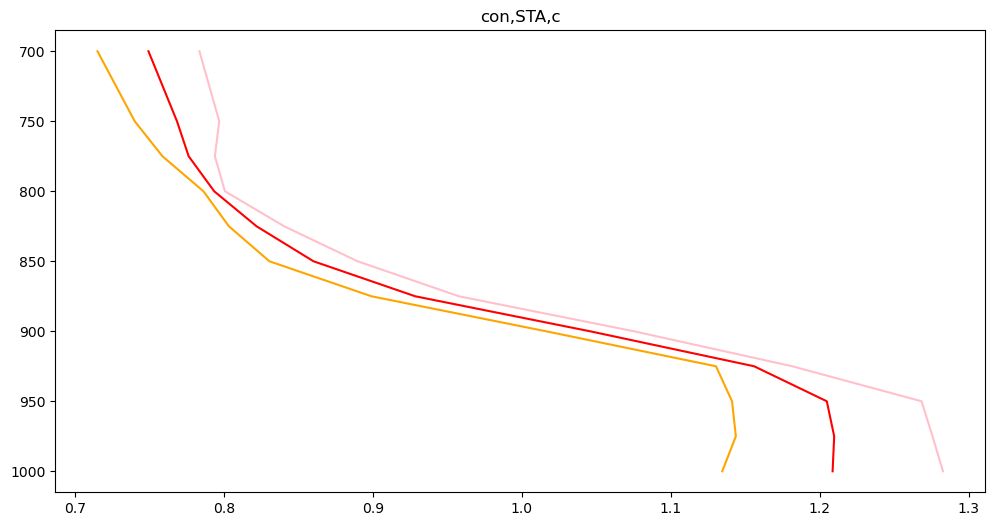

In [8]:
# load in the data in nested dicts
in_data_dict = {}

for domain in ['15deg', 'STA']:

    in_data_dict[domain] = {}
    
    for szn in ['w', 'c']:

        in_data_dict[domain][szn] = {}

        for ev_type in ['mhw', 'thw', 'con']:

            print('--------------------------')
            print(domain, szn, ev_type)
            in_data_dict[domain][szn][ev_type] = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/{}_{}_Tprofile_anom_ds_{}.nc'.format(ev_type, domain, szn)).Tx_anom

            # I guess I can compute the bootstrapped stuff here as well...
            binned_boots, bin_midpoints, bin_nobs = bin_lat_scatters_densitywtd_bootCI_forTProfiles(latbins=lbins, lats=df.LAT.values, lons=df.LON.values, 
                                                            dat=in_data_dict[domain][szn][ev_type].data, nboot=1000, radius_deg=3.0)

            # put into DataArray
            bin_boot_da = xr.DataArray(binned_boots, dims=['lat bin', 'boot', 'level'], coords={'lat bin':bin_midpoints, 'boot':np.array(range(1000)), 'level':in_data_dict[domain][szn][ev_type].level})


            # aggregate bins to global-mean scale, weighting by bin land area
            globalmean_boot_da = bin_boot_da.weighted(np.cos(np.deg2rad(bin_boot_da['lat bin']))).mean(dim='lat bin')

            # now, take bootstrapped mean and 95% CI of the global profiles
            globalmean_bootprofile_med = globalmean_boot_da.quantile(0.5, dim='boot')
            globalmean_bootprofile_hici = globalmean_boot_da.quantile(0.975, dim='boot')
            globalmean_bootprofile_loci = globalmean_boot_da.quantile(0.025, dim='boot')

            # now plot...
            levels = in_data_dict[domain][szn][ev_type].level
            fig, ax = plt.subplots()
            ax.plot(globalmean_bootprofile_med, levels, color='red')
            ax.plot(globalmean_bootprofile_hici, levels, color='pink')
            ax.plot(globalmean_bootprofile_loci, levels, color='orange')
            ax.set(title='{},{},{}'.format(ev_type, domain, szn))
            ax.invert_yaxis()
            plt.pause(0.1)

            
            # ... save so that I can analyze/plot over in the Fig. 3 script
            ds_out = bin_boot_da.to_dataset(name='Tx_anom')
            ds_out.attrs['script'] = script
            now = datetime.now()
            ds_out.attrs['timestamp'] = now.strftime("%Y-%m-%d %H:%M:%S")
            ds_out.to_netcdf('/dx02/data/nsiegert/coastal_mhw_data/{}_{}_Bootstrap_Tprofile_anom_ds_{}.nc'.format(ev_type, domain, szn))

In [9]:
domain = 'STA'
szn = 'c'
ev_type = 'con'

In [10]:
levels = in_data_dict[domain][szn][ev_type].level

In [11]:
# a test data for one level
htst = in_data_dict[domain][szn][ev_type].sel(level=700.)
htst

<xarray.DataArray 'Tx_anom' (staid: 1474)> Size: 12kB
array([ 0.781386,  1.012221,  1.337626, ...,  0.226192, -0.105079,  0.880924])
Coordinates:
  * staid    (staid) <U12 71kB '010014-99999' '011020-99999' ... '999999-12946'
    level    float64 8B 700.0

In [12]:
# do the normal "bin_lat_scatters" stuff but this time I have multidimensional data and I want to sample a station's entire profile anom. rather than just 
# doing it separately level-by-level

In [13]:
latbins = lbins
lats = df.LAT.values
lons = df.LON.values
dat = in_data_dict[domain][szn][ev_type].data
nboot = 1000
radius_deg = 3.0

In [14]:
def bin_lat_scatters_densitywtd_bootCI_forTProfiles(latbins, lats, lons, dat, nboot, radius_deg):
    '''
    Like "bin_lat_scatters_densitywtd_bootCI()" but this one takes in a 2-d "dat" array so that I can randomly sample T profiles (maintaining the spatial structure,
     rather than generating a bootstrapped mean level-by-level)

    6/22/26
    '''

    # random seed
    rng = np.random.default_rng(27)
    
    # empty arrays to hold output
    binned_boots = np.zeros(shape=(len(latbins)-1, nboot, 12)) * np.nan # dims = [lat_bin, bootstrap_mean_draw, level]
    bin_midpoints = np.zeros(len(latbins)-1)
    bin_n_obs = np.zeros(len(latbins)-1)
    
    i = 0
    
    # for each lat bin
    while i < len(latbins)-1:
    
        # sel lat bin bounds, generate bin mask
        bot_bin = latbins[i]
        top_bin = latbins[i+1]
        binmask = (lats >= bot_bin) * (lats < top_bin)
    
    #        print(i, bot_bin, top_bin)
    
        # skip bin if there are no obs in that bin
        if np.sum(binmask) == 0:
    #            print('skip this bin.')
            bin_midpoints[i] = ((bot_bin+top_bin)/2)
            bin_n_obs[i] = 0
            i += 1
            continue
    
        # set vals to send to bootstrap
        dat_bin = dat[binmask] # this still makes 2-d, nice
        lats_bin = lats[binmask]
        lons_bin = lons[binmask]
        
        # distance-weights for this lat bin
        weights = compute_density_weights(lats=lats_bin, lons=lons_bin, radius_deg=radius_deg)
        
        # empty array to store bootstrap draws
        boot_stats = (np.zeros(shape=(nboot, 12)) * np.nan) # shape is now [nboot, level]
        
        # do the bootstrapped mean
        for b in range(nboot):
            idx = rng.choice(len(dat_bin), size=len(dat_bin), replace=True, p=weights)
        
            # 6/21/26 - adding another step to ignore inf when taking the mean
            ddd = dat_bin[idx]
            no_inf_mask = np.logical_not(np.isinf(ddd))
            ddd_masked = np.where(no_inf_mask, ddd, np.nan) # replace any inf's with NaN
        
            # compute the bootstrapped mean
            boot_stats[b, :] = np.nanmean(ddd_masked, axis=0) 
        
        # add the results to the output arrays
        binned_boots[i, :, :] = boot_stats
        bin_midpoints[i] = ((bot_bin+top_bin)/2)
        bin_n_obs[i] = np.sum(binmask)
    
        # update counter
        i += 1 

        return binned_boots, bin_midpoints, bin_n_obs

In [15]:
#### FUNCTION TEXT BELOW

In [16]:
# Dat will now be a 2-d array of shape [staid, level]

In [17]:
# random seed
rng = np.random.default_rng(27)

# empty arrays to hold output
binned_boots = np.zeros(shape=(len(latbins)-1, nboot, 12)) * np.nan # dims = [lat_bin, bootstrap_mean_draw, level]
bin_midpoints = np.zeros(len(latbins)-1)
bin_n_obs = np.zeros(len(latbins)-1)

i = 0

# for each lat bin
while i < len(latbins)-1:

    # sel lat bin bounds, generate bin mask
    bot_bin = latbins[i]
    top_bin = latbins[i+1]
    binmask = (lats >= bot_bin) * (lats < top_bin)

#        print(i, bot_bin, top_bin)

    # skip bin if there are no obs in that bin
    if np.sum(binmask) == 0:
#            print('skip this bin.')
        bin_midpoints[i] = ((bot_bin+top_bin)/2)
        bin_n_obs[i] = 0
        i += 1
        continue

    # set vals to send to bootstrap
    dat_bin = dat[binmask] # this still makes 2-d, nice
    lats_bin = lats[binmask]
    lons_bin = lons[binmask]
    
    # distance-weights for this lat bin
    weights = compute_density_weights(lats=lats_bin, lons=lons_bin, radius_deg=radius_deg)
    
    # empty array to store bootstrap draws
    boot_stats = (np.zeros(shape=(nboot, 12)) * np.nan) # shape is now [nboot, level]
    
    # do the bootstrapped mean
    for b in range(nboot):
        idx = rng.choice(len(dat_bin), size=len(dat_bin), replace=True, p=weights)
    
        # 6/21/26 - adding another step to ignore inf when taking the mean
        ddd = dat_bin[idx]
        no_inf_mask = np.logical_not(np.isinf(ddd))
        ddd_masked = np.where(no_inf_mask, ddd, np.nan) # replace any inf's with NaN
    
        # compute the bootstrapped mean
        boot_stats[b, :] = np.nanmean(ddd_masked, axis=0) 
    
    # add the results to the output arrays
    binned_boots[i, :, :] = boot_stats
    bin_midpoints[i] = ((bot_bin+top_bin)/2)
    bin_n_obs[i] = np.sum(binmask)

    # update counter
    i += 1 

In [18]:
# put into DataArray
bin_boot_da = xr.DataArray(binned_boots, dims=['lat bin', 'boot', 'level'], coords={'lat bin':bin_midpoints, 'boot':np.array(range(1000)), 'level':levels})

In [19]:
# aggregate bins to global-mean scale, weighting by bin land area
globalmean_boot_da = bin_boot_da.weighted(np.cos(np.deg2rad(bin_boot_da['lat bin']))).mean(dim='lat bin')

In [20]:
# now, take bootstrapped mean and 95% CI of the global profiles
globalmean_bootprofile_med = globalmean_boot_da.quantile(0.5, dim='boot')
globalmean_bootprofile_hici = globalmean_boot_da.quantile(0.975, dim='boot')
globalmean_bootprofile_loci = globalmean_boot_da.quantile(0.025, dim='boot')

In [21]:
# "raw mean" as a comparison
raw_mean_profile_da = in_data_dict[domain][szn][ev_type].mean(dim='staid')

In [8]:
# interactive plotting stuff 
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import colors
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
from matplotlib import rcParams
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.lines import Line2D 

#import matplotlib.dates as mdates
%matplotlib inline
plt.rcParams['figure.figsize'] = 12, 6
#%config InlineBackend.figure_format = 'retina'

import cartopy
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point

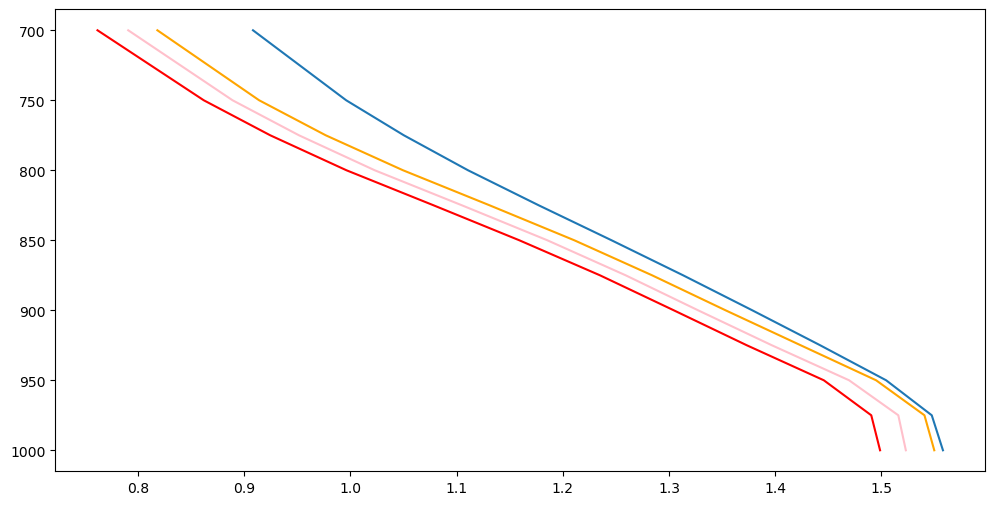

In [23]:
fig, ax = plt.subplots()

ax.plot(raw_mean_profile_da, levels)
ax.plot(globalmean_bootprofile_med, levels, color='pink')
ax.plot(globalmean_bootprofile_hici, levels, color='orange')
ax.plot(globalmean_bootprofile_loci, levels, color='red')


ax.invert_yaxis()

# is that the same as what I'd gotten before?

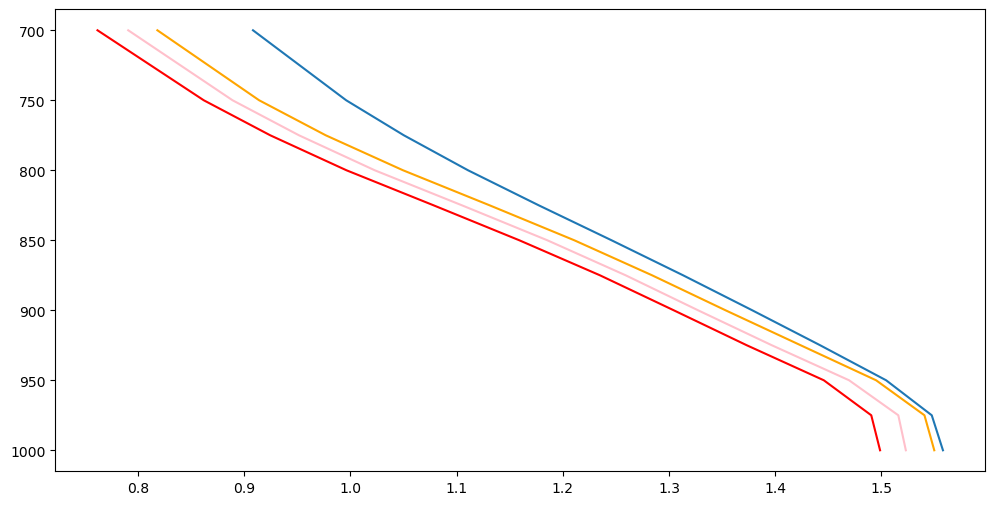

In [31]:
fig, ax = plt.subplots()

ax.plot(raw_mean_profile_da, levels)
ax.plot(globalmean_bootprofile_med, levels, color='pink')
ax.plot(globalmean_bootprofile_hici, levels, color='orange')
ax.plot(globalmean_bootprofile_loci, levels, color='red')


ax.invert_yaxis()